# DS108 - Chọn lọc đặc trưng

In [1]:
# =============================================================================
# 0. Imports & Configuration
# =============================================================================

from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (11, 5.8),
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 120,
})

try:
    from lightgbm import LGBMClassifier, LGBMRegressor
except ImportError as exc:
    raise ImportError(
        "Notebook này cần thư viện lightgbm. Hãy cài bằng: pip install lightgbm"
    ) from exc

CURRENT_DIR = Path.cwd()
BASE_DIR = CURRENT_DIR.parent if CURRENT_DIR.name.lower() in {"notebooks", "src"} else CURRENT_DIR
DATA_PATH = BASE_DIR / "data" / "features" / "feature_engineered_data.csv"

RAIN_THRESHOLD = 0.1

TRAIN_END = pd.Timestamp("2023-01-01")
VALID_END = pd.Timestamp("2024-01-01")

RANDOM_STATE = 42

TARGET_SELECTED_N = 46
HIGH_MISSING_THRESHOLD = 0.40
CORR_PRUNE_THRESHOLD = 0.95

print("BASE_DIR :", BASE_DIR)
print("DATA_PATH:", DATA_PATH)

BASE_DIR : c:\Users\Laptop\PycharmProjects\DS108
DATA_PATH: c:\Users\Laptop\PycharmProjects\DS108\data\features\feature_engineered_data.csv


In [2]:
# =============================================================================
# Helper functions
# =============================================================================

def clean_axis(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, pad=12, fontweight="bold")
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.25)
    sns.despine(ax=ax)
    return ax


def display_section(title: str):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)


def normalize_score(series: pd.Series) -> pd.Series:
    series = series.fillna(0).astype(float)
    max_value = series.max()
    if not np.isfinite(max_value) or max_value <= 0:
        return pd.Series(0.0, index=series.index)
    return series / max_value


def get_gain_importance(model, feature_names: list[str], name: str) -> pd.DataFrame:
    importance = getattr(model, "feature_importances_", None)
    if importance is None:
        importance = np.zeros(len(feature_names))

    return pd.DataFrame({
        "feature": feature_names,
        name: importance.astype(float),
    })


def regression_metrics(y_true, y_pred) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    denom = np.sum(np.abs(y_true))
    wape = np.sum(np.abs(y_true - y_pred)) / denom * 100 if denom > 0 else np.nan
    r2 = r2_score(y_true, y_pred)
    bias = np.mean(y_pred - y_true)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "WAPE_percent": wape,
        "R2": r2,
        "Bias": bias,
    }


def select_with_correlation_pruning(
    ranked_features: list[str],
    corr_abs: pd.DataFrame,
    target_k: int,
    corr_threshold: float = 0.95,
) -> tuple[list[str], list[dict]]:
    selected = []
    removed = []

    for feature in ranked_features:
        if feature not in corr_abs.index:
            continue

        if len(selected) >= target_k:
            break

        too_similar_to = None
        for kept_feature in selected:
            corr_value = corr_abs.loc[feature, kept_feature]
            if pd.notna(corr_value) and corr_value >= corr_threshold:
                too_similar_to = kept_feature
                break

        if too_similar_to is None:
            selected.append(feature)
        else:
            removed.append({
                "removed_feature": feature,
                "kept_feature": too_similar_to,
                "abs_spearman_corr": corr_abs.loc[feature, too_similar_to],
                "reason": f"abs_corr >= {corr_threshold}",
            })

    return selected, removed

## 1. Load dữ liệu và tạo split thời gian

Nguyên tắc:

- Chỉ dùng train/validation để chọn feature.
- Test 2024 được giữ riêng, chỉ dùng để đánh giá cuối trong file model.
- Target chính là `PRCP`.
- Nhãn mưa dùng rule `PRCP >= 0.1 mm`.

In [3]:
# =============================================================================
# 1. Load data
# =============================================================================

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy file dữ liệu: {DATA_PATH}")

df_raw = pd.read_csv(DATA_PATH)

required_cols = {"time", "PRCP"}
missing_required = sorted(required_cols - set(df_raw.columns))
if missing_required:
    raise ValueError(f"Thiếu cột bắt buộc: {missing_required}")

df_raw["time"] = pd.to_datetime(df_raw["time"], errors="coerce")
df_raw["PRCP"] = pd.to_numeric(df_raw["PRCP"], errors="coerce")

if df_raw["time"].isna().any():
    raise ValueError("Cột time có giá trị datetime không hợp lệ.")

if "STATION" in df_raw.columns:
    df_raw["STATION"] = df_raw["STATION"].astype(str)

df_raw["rain_label"] = np.where(
    df_raw["PRCP"].notna(),
    (df_raw["PRCP"] >= RAIN_THRESHOLD).astype(int),
    np.nan,
)

df_raw["target_log1p_prcp"] = np.log1p(df_raw["PRCP"].clip(lower=0))

df_raw["split"] = np.select(
    [
        df_raw["time"] < TRAIN_END,
        (df_raw["time"] >= TRAIN_END) & (df_raw["time"] < VALID_END),
        df_raw["time"] >= VALID_END,
    ],
    ["train_2015_2022", "valid_2023", "test_2024"],
    default="outside_split",
)

# Chỉ giữ dòng có target hợp lệ cho feature selection
df = df_raw.dropna(subset=["PRCP", "rain_label", "target_log1p_prcp"]).copy()

train_df = df[df["split"].eq("train_2015_2022")].copy()
valid_df = df[df["split"].eq("valid_2023")].copy()
test_df = df[df["split"].eq("test_2024")].copy()

split_summary = (
    df.groupby("split")
    .agg(
        n_rows=("PRCP", "size"),
        time_min=("time", "min"),
        time_max=("time", "max"),
        rain_rate=("rain_label", "mean"),
        mean_prcp=("PRCP", "mean"),
        median_prcp=("PRCP", "median"),
        max_prcp=("PRCP", "max"),
    )
    .reset_index()
)

display(split_summary)

print("Raw shape         :", df_raw.shape)
print("Valid target shape:", df.shape)
print("Train rows        :", len(train_df))
print("Valid rows        :", len(valid_df))
print("Test rows         :", len(test_df), "(không dùng để chọn feature)")

,split,n_rows,time_min,time_max,rain_rate,mean_prcp,median_prcp,max_prcp
0,test_2024,1741,2024-01-01,2024-12-31,0.383113,5.929974,0.0,295.402
1,train_2015_2022,14361,2015-01-01,2022-12-31,0.378038,5.856061,0.0,381.254
2,valid_2023,1794,2023-01-01,2023-12-31,0.398551,5.465672,0.0,210.058


Raw shape         : (18265, 80)
Valid target shape: (17896, 80)
Train rows        : 14361
Valid rows        : 1794
Test rows         : 1741 (không dùng để chọn feature)


## 2. Loại cột leakage và tạo candidate features

Các cột bị loại khỏi feature:

- Định danh và thời gian thô: `STATION`, `time`.
- Target và biến phụ liên quan target: `PRCP`, `target_*`, `rain_label`, `target_log1p_prcp`.
- `PRCP_impute`: chỉ dùng để tạo lag/rolling trong pipeline, không đưa trực tiếp vào model.

In [4]:
# =============================================================================
# 2. Candidate feature construction
# =============================================================================

LEAKAGE_OR_NON_FEATURE_COLS = {
    "STATION",
    "time",
    "DATE",
    "split",
    "rain_label",
    "target_log1p_prcp",
    "PRCP",
    "PRCP_impute",
    "target_1stage_prcp_mm",
    "target_stage1_rain_label",
    "target_stage2_prcp_log1p",
}

candidate_features = [
    col for col in df.columns
    if col not in LEAKAGE_OR_NON_FEATURE_COLS
    and pd.api.types.is_numeric_dtype(df[col])
]

candidate_report = pd.DataFrame({
    "group": ["all_columns", "candidate_numeric_features"],
    "n_columns": [df.shape[1], len(candidate_features)],
})

display(candidate_report)

leakage_overlap = sorted(set(candidate_features) & LEAKAGE_OR_NON_FEATURE_COLS)
if leakage_overlap:
    raise ValueError(f"Leakage columns still included: {leakage_overlap}")

print("Candidate features:", len(candidate_features))
print(candidate_features[:30])

,group,n_columns
0,all_columns,80
1,candidate_numeric_features,70


Candidate features: 70
['LATITUDE', 'LONGITUDE', 'ELEVATION', 'TEMP', 'WDSP', 'DEWP', 'STP', 'SLP', 'VISIB', 'u10', 'v10', 'z', 'lsm', 'z_500', 't_500', 'q_500', 'u_500', 'v_500', 'w_500', 'z_850', 't_850', 'q_850', 'u_850', 'v_850', 'w_850', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'moist_convection_500']


## 3. Bộ lọc kỹ thuật ban đầu

Mục tiêu:

- Loại feature hằng số.
- Loại feature thiếu quá nhiều trên train set.
- Loại feature có toàn giá trị thiếu hoặc không hợp lệ.

In [5]:
# =============================================================================
# 3. Basic technical filters
# =============================================================================

filter_rows = []
kept_features = []

for col in candidate_features:
    train_col = pd.to_numeric(train_df[col], errors="coerce").replace([np.inf, -np.inf], np.nan)

    missing_rate = train_col.isna().mean()
    n_unique = train_col.nunique(dropna=True)

    if missing_rate >= 1.0:
        decision = "drop_all_missing"
    elif missing_rate > HIGH_MISSING_THRESHOLD:
        decision = "drop_high_missing"
    elif n_unique <= 1:
        decision = "drop_constant"
    else:
        decision = "keep"
        kept_features.append(col)

    filter_rows.append({
        "feature": col,
        "missing_rate_train": missing_rate,
        "n_unique_train": n_unique,
        "decision": decision,
    })

filter_report = pd.DataFrame(filter_rows).sort_values(
    ["decision", "missing_rate_train"],
    ascending=[True, False],
)

display(filter_report["decision"].value_counts().rename_axis("decision").reset_index(name="n_features"))
display(filter_report.sort_values("missing_rate_train", ascending=False).head(30))

print("Features before filter:", len(candidate_features))
print("Features after filter :", len(kept_features))

,decision,n_features
0,keep,70


,feature,missing_rate_train,n_unique_train,decision
43,PRCP_lag_2,0.000557,418,keep
53,SLP_lag_2,0.000557,461,keep
59,moisture_flux_850_lag_2,0.000557,14353,keep
57,dew_point_depression_lag_2,0.000557,772,keep
55,VISIB_lag_2,0.000557,100,keep
45,u_850_lag_2,0.000557,13861,keep
51,DEWP_lag_2,0.000557,549,keep
49,TEMP_lag_2,0.000557,562,keep
47,v_850_lag_2,0.000557,13614,keep
58,moisture_flux_850_lag_1,0.000279,14357,keep


Features before filter: 70
Features after filter : 70


## 4. Chuẩn bị X/y cho feature selection

Notebook này dùng:

- `X_train`, `y_train_reg` cho hồi quy trực tiếp PRCP.
- `y_train_cls` cho phân loại mưa/không mưa.
- `X_train_wet`, `y_train_wet` cho hồi quy lượng mưa trên ngày có mưa.

In [6]:
# =============================================================================
# 4. Prepare train/valid matrices
# =============================================================================

X_train = train_df[kept_features].replace([np.inf, -np.inf], np.nan)
X_valid = valid_df[kept_features].replace([np.inf, -np.inf], np.nan)

y_train_reg = train_df["PRCP"].astype(float)
y_valid_reg = valid_df["PRCP"].astype(float)

y_train_cls = train_df["rain_label"].astype(int)
y_valid_cls = valid_df["rain_label"].astype(int)

wet_train_mask = train_df["rain_label"].eq(1)
wet_valid_mask = valid_df["rain_label"].eq(1)

X_train_wet = X_train.loc[wet_train_mask]
y_train_wet = train_df.loc[wet_train_mask, "target_log1p_prcp"].astype(float)

X_valid_wet = X_valid.loc[wet_valid_mask]
y_valid_wet = valid_df.loc[wet_valid_mask, "target_log1p_prcp"].astype(float)

print("X_train     :", X_train.shape)
print("X_valid     :", X_valid.shape)
print("X_train_wet :", X_train_wet.shape)
print("X_valid_wet :", X_valid_wet.shape)
print("Rain rate train:", y_train_cls.mean())
print("Rain rate valid:", y_valid_cls.mean())

X_train     : (14361, 70)
X_valid     : (1794, 70)
X_train_wet : (5429, 70)
X_valid_wet : (715, 70)
Rain rate train: 0.37803774110437993
Rain rate valid: 0.39855072463768115


## 5. Tính feature importance bằng LightGBM

Dùng ba mô hình để bao phủ đúng bản chất bài toán mưa:

1. **One-stage Tweedie Regression**: dự báo trực tiếp lượng mưa.
2. **Stage 1 Classifier**: dự báo xác suất có mưa.
3. **Stage 2 Regressor**: dự báo cường độ mưa trên các ngày có mưa.

Test set không được sử dụng ở bước này.

In [7]:
# =============================================================================
# 5. LightGBM feature importance
# =============================================================================

reg_model = LGBMRegressor(
    objective="tweedie",
    tweedie_variance_power=1.3,
    n_estimators=350,
    learning_rate=0.04,
    num_leaves=31,
    min_child_samples=30,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

cls_model = LGBMClassifier(
    objective="binary",
    n_estimators=350,
    learning_rate=0.04,
    num_leaves=31,
    min_child_samples=30,
    subsample=0.9,
    colsample_bytree=0.9,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

wet_model = LGBMRegressor(
    objective="regression",
    n_estimators=350,
    learning_rate=0.04,
    num_leaves=31,
    min_child_samples=30,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

reg_model.fit(X_train, y_train_reg)
cls_model.fit(X_train, y_train_cls)
wet_model.fit(X_train_wet, y_train_wet)

importance_reg = get_gain_importance(reg_model, kept_features, "importance_tweedie")
importance_cls = get_gain_importance(cls_model, kept_features, "importance_stage1_cls")
importance_wet = get_gain_importance(wet_model, kept_features, "importance_stage2_wet")

importance_df = (
    importance_reg
    .merge(importance_cls, on="feature", how="outer")
    .merge(importance_wet, on="feature", how="outer")
    .fillna(0)
)

display(importance_df.head())

,feature,importance_tweedie,importance_stage1_cls,importance_stage2_wet
0,DEWP,222.0,143.0,166.0
1,DEWP_3d_mean,140.0,112.0,146.0
2,DEWP_lag_1,245.0,143.0,229.0
3,DEWP_lag_2,127.0,139.0,144.0
4,ELEVATION,2.0,1.0,5.0


## 6. Kiểm tra nhanh chất lượng mô hình chọn feature trên validation

Mục tiêu của cell này không phải báo cáo model cuối, mà để đảm bảo mô hình dùng cho importance học được tín hiệu hợp lý.

In [8]:
# =============================================================================
# 6. Validation sanity check for selector models
# =============================================================================

valid_pred_reg = np.clip(reg_model.predict(X_valid), 0, None)

valid_pred_cls_proba = cls_model.predict_proba(X_valid)[:, 1]
valid_pred_wet_log = wet_model.predict(X_valid)
valid_pred_wet_amount = np.expm1(valid_pred_wet_log)
valid_pred_two_stage = np.clip(valid_pred_cls_proba * valid_pred_wet_amount, 0, None)

reg_metrics = regression_metrics(y_valid_reg, valid_pred_reg)
two_stage_metrics = regression_metrics(y_valid_reg, valid_pred_two_stage)

try:
    cls_auc = roc_auc_score(y_valid_cls, valid_pred_cls_proba)
except ValueError:
    cls_auc = np.nan

try:
    cls_pr_auc = average_precision_score(y_valid_cls, valid_pred_cls_proba)
except ValueError:
    cls_pr_auc = np.nan

validation_sanity = pd.DataFrame([
    {"model": "Selector Tweedie Regression", **reg_metrics},
    {"model": "Selector Two-stage Expected Rainfall", **two_stage_metrics},
])

classification_sanity = pd.DataFrame([
    {
        "model": "Selector Stage 1 Classifier",
        "ROC_AUC": cls_auc,
        "PR_AUC": cls_pr_auc,
        "valid_rain_rate": y_valid_cls.mean(),
    }
])

display(validation_sanity)
display(classification_sanity)

,model,MAE,RMSE,WAPE_percent,R2,Bias
0,Selector Tweedie Regression,3.815723,11.459841,69.812514,0.556584,-1.141443
1,Selector Two-stage Expected Rainfall,3.848383,11.977096,70.410049,0.515652,-1.826411


,model,ROC_AUC,PR_AUC,valid_rain_rate
0,Selector Stage 1 Classifier,0.927078,0.89082,0.398551


## 7. Tính điểm tổng hợp cho feature

Điểm tổng hợp gồm:

- Importance từ Tweedie regression.
- Importance từ classifier mưa/không mưa.
- Importance từ wet-day regression.
- Spearman correlation với `log1p(PRCP)` trên train set.

Correlation chỉ là tín hiệu phụ, không phải tiêu chí duy nhất.

In [9]:
# =============================================================================
# 7. Combined feature score
# =============================================================================

corr_rows = []
for col in kept_features:
    x = pd.to_numeric(train_df[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
    y_log = np.log1p(train_df["PRCP"].clip(lower=0))
    y_cls = train_df["rain_label"]

    corr_rows.append({
        "feature": col,
        "spearman_log1p_prcp": x.corr(y_log, method="spearman"),
        "spearman_rain_label": x.corr(y_cls, method="spearman"),
        "missing_rate_train": train_df[col].isna().mean(),
        "n_unique_train": train_df[col].nunique(dropna=True),
    })

corr_df = pd.DataFrame(corr_rows)

score_df = (
    importance_df
    .merge(corr_df, on="feature", how="left")
    .fillna(0)
)

score_df["importance_tweedie_norm"] = normalize_score(score_df["importance_tweedie"])
score_df["importance_stage1_cls_norm"] = normalize_score(score_df["importance_stage1_cls"])
score_df["importance_stage2_wet_norm"] = normalize_score(score_df["importance_stage2_wet"])
score_df["corr_log1p_norm"] = normalize_score(score_df["spearman_log1p_prcp"].abs())
score_df["corr_rain_label_norm"] = normalize_score(score_df["spearman_rain_label"].abs())

score_df["combined_score"] = (
    0.35 * score_df["importance_tweedie_norm"]
    + 0.25 * score_df["importance_stage1_cls_norm"]
    + 0.25 * score_df["importance_stage2_wet_norm"]
    + 0.10 * score_df["corr_log1p_norm"]
    + 0.05 * score_df["corr_rain_label_norm"]
)

score_df = score_df.sort_values("combined_score", ascending=False).reset_index(drop=True)

display(score_df.head(30))

,feature,importance_tweedie,importance_stage1_cls,importance_stage2_wet,spearman_log1p_prcp,spearman_rain_label,missing_rate_train,n_unique_train,importance_tweedie_norm,importance_stage1_cls_norm,importance_stage2_wet_norm,corr_log1p_norm,corr_rain_label_norm,combined_score
0,dew_point_depression,571.0,673.0,421.0,-0.551266,-0.525504,0.000000,648,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,VISIB_lag_1,376.0,395.0,311.0,-0.350434,-0.341224,0.000279,100,0.658494,0.586924,0.738717,0.635690,0.649328,0.657919
2,TEMP,369.0,413.0,283.0,-0.208384,-0.206392,0.000000,435,0.646235,0.613670,0.672209,0.378011,0.392750,0.605091
3,VISIB,340.0,301.0,279.0,-0.398893,-0.374862,0.000000,100,0.595447,0.447251,0.662708,0.723594,0.713337,0.593922
4,moist_convection_850_3d_mean,275.0,251.0,246.0,-0.224875,-0.213321,0.000279,14306,0.481611,0.372957,0.584323,0.407925,0.405935,0.468973
5,moisture_flux_850,254.0,241.0,227.0,0.297514,0.277285,0.000000,14361,0.444834,0.358098,0.539192,0.539692,0.527656,0.460366
6,v10,258.0,263.0,207.0,-0.219653,-0.220470,0.000000,12898,0.451839,0.390788,0.491686,0.398451,0.419540,0.439584
7,q_500,249.0,186.0,205.0,0.356612,0.316681,0.000000,68,0.436077,0.276374,0.486936,0.646896,0.602622,0.438275
8,PRCP_lag_1,198.0,165.0,214.0,0.453910,0.431191,0.000279,421,0.346760,0.245171,0.508314,0.823396,0.820529,0.433103
9,u10,247.0,206.0,244.0,0.158128,0.149113,0.000000,12348,0.432574,0.306092,0.579572,0.286845,0.283752,0.415689


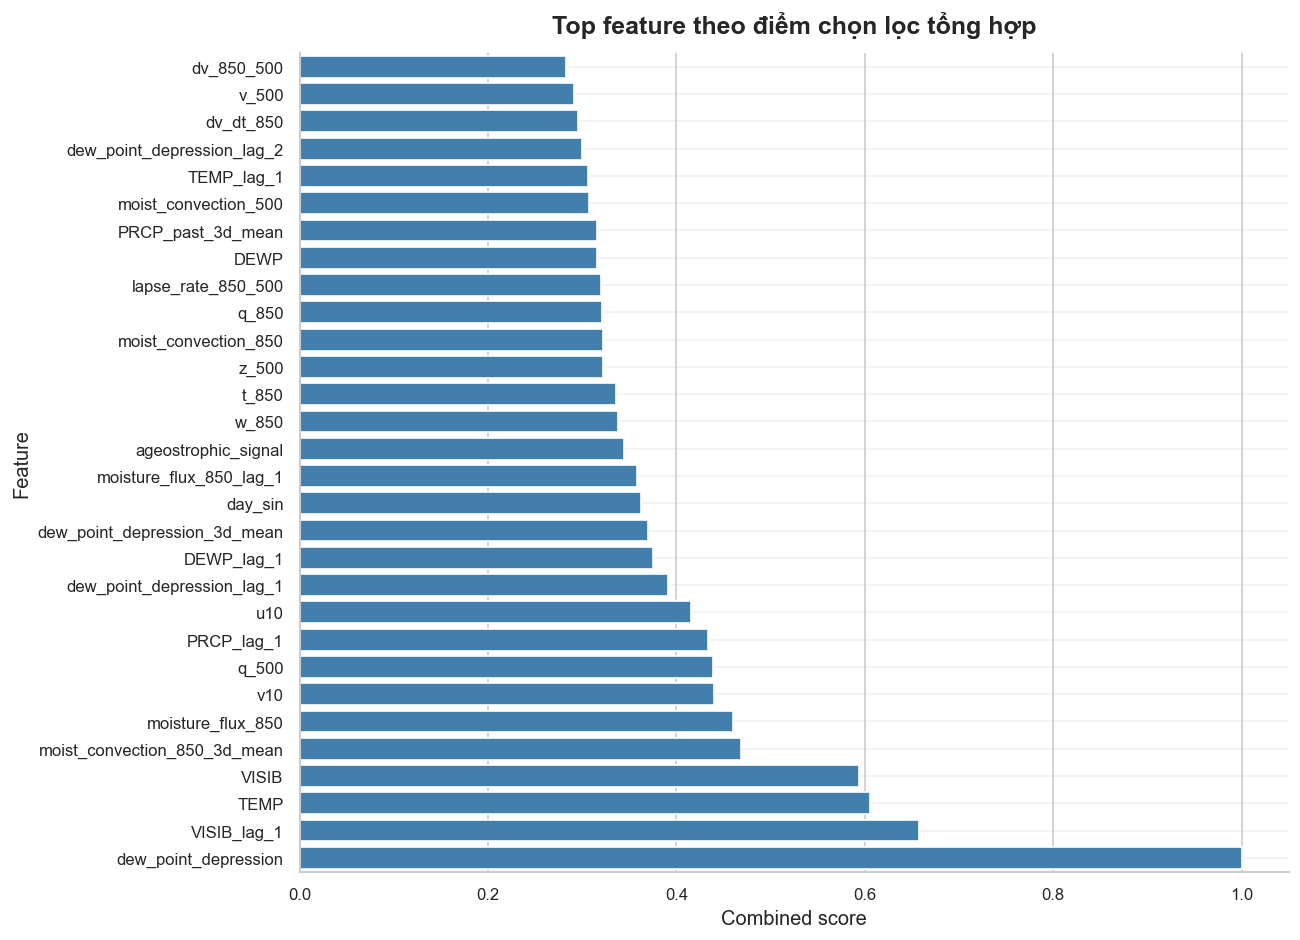

In [10]:
# Plot top feature scores

top_score_plot = score_df.head(30).iloc[::-1]

plt.figure(figsize=(11, 8))
ax = sns.barplot(
    data=top_score_plot,
    x="combined_score",
    y="feature",
    color="#3182BD",
)
clean_axis(ax, "Top feature theo điểm chọn lọc tổng hợp", "Combined score", "Feature")
plt.tight_layout()
plt.show()

## 8. Correlation pruning

Mục tiêu:

- Giảm trùng lặp giữa các feature có tương quan quá cao.
- Giữ feature có điểm tổng hợp cao hơn.
- Chỉ dùng train set để tránh leakage.

In [11]:
# =============================================================================
# 8. Correlation pruning
# =============================================================================

ranked_features = score_df["feature"].tolist()

corr_abs = train_df[kept_features].corr(method="spearman", numeric_only=True).abs()
corr_abs = corr_abs.replace([np.inf, -np.inf], np.nan).fillna(0)

selected_features, removed_by_corr = select_with_correlation_pruning(
    ranked_features=ranked_features,
    corr_abs=corr_abs,
    target_k=TARGET_SELECTED_N,
    corr_threshold=CORR_PRUNE_THRESHOLD,
)

removed_by_corr_df = pd.DataFrame(removed_by_corr)

selected_score_df = (
    score_df[score_df["feature"].isin(selected_features)]
    .copy()
    .assign(selection_rank=lambda x: x["feature"].map({f: i + 1 for i, f in enumerate(selected_features)}))
    .sort_values("selection_rank")
)

display(selected_score_df[[
    "selection_rank",
    "feature",
    "combined_score",
    "importance_tweedie",
    "importance_stage1_cls",
    "importance_stage2_wet",
    "spearman_log1p_prcp",
    "spearman_rain_label",
]])

print("Selected features:", len(selected_features))

if not removed_by_corr_df.empty:
    display(removed_by_corr_df.head(30))
else:
    print("Không có feature nào bị loại bởi correlation pruning trước khi đạt target_k.")

,selection_rank,feature,combined_score,importance_tweedie,importance_stage1_cls,importance_stage2_wet,spearman_log1p_prcp,spearman_rain_label
0,1,dew_point_depression,1.000000,571.0,673.0,421.0,-0.551266,-0.525504
1,2,VISIB_lag_1,0.657919,376.0,395.0,311.0,-0.350434,-0.341224
2,3,TEMP,0.605091,369.0,413.0,283.0,-0.208384,-0.206392
3,4,VISIB,0.593922,340.0,301.0,279.0,-0.398893,-0.374862
4,5,moist_convection_850_3d_mean,0.468973,275.0,251.0,246.0,-0.224875,-0.213321
5,6,moisture_flux_850,0.460366,254.0,241.0,227.0,0.297514,0.277285
6,7,v10,0.439584,258.0,263.0,207.0,-0.219653,-0.220470
7,8,q_500,0.438275,249.0,186.0,205.0,0.356612,0.316681
8,9,PRCP_lag_1,0.433103,198.0,165.0,214.0,0.453910,0.431191
9,10,u10,0.415689,247.0,206.0,244.0,0.158128,0.149113


Selected features: 46


,removed_feature,kept_feature,abs_spearman_corr,reason
0,moist_convection_850,w_850,0.992906,abs_corr >= 0.95
1,TEMP_3d_mean,TEMP_lag_1,0.958229,abs_corr >= 0.95
2,DEWP_3d_mean,DEWP_lag_2,0.973748,abs_corr >= 0.95


## 9. Kiểm tra selected features

Cell này kiểm tra:

- Không có leakage columns.
- Tất cả selected features tồn tại trong dataset.
- Selected features là numeric.
- Không có feature trùng lặp.

In [12]:
# =============================================================================
# 9. Final checks
# =============================================================================

selected_set = set(selected_features)

check_rows = []

check_rows.append({
    "check": "n_selected_features",
    "value": len(selected_features),
    "status": "PASS" if len(selected_features) == TARGET_SELECTED_N else "WARNING",
})

check_rows.append({
    "check": "no_duplicate_features",
    "value": len(selected_features) == len(selected_set),
    "status": "PASS" if len(selected_features) == len(selected_set) else "FAIL",
})

leakage_selected = sorted(selected_set & LEAKAGE_OR_NON_FEATURE_COLS)
check_rows.append({
    "check": "no_leakage_columns",
    "value": leakage_selected,
    "status": "PASS" if not leakage_selected else "FAIL",
})

missing_selected = sorted(selected_set - set(df.columns))
check_rows.append({
    "check": "all_selected_exist_in_dataframe",
    "value": missing_selected,
    "status": "PASS" if not missing_selected else "FAIL",
})

non_numeric_selected = [
    col for col in selected_features
    if col in df.columns and not pd.api.types.is_numeric_dtype(df[col])
]
check_rows.append({
    "check": "all_selected_are_numeric",
    "value": non_numeric_selected,
    "status": "PASS" if not non_numeric_selected else "FAIL",
})

final_checks = pd.DataFrame(check_rows)
display(final_checks)

if (final_checks["status"] == "FAIL").any():
    raise ValueError("Có lỗi trong selected features. Hãy kiểm tra bảng final_checks.")

,check,value,status
0,n_selected_features,46,PASS
1,no_duplicate_features,True,PASS
2,no_leakage_columns,[],PASS
3,all_selected_exist_in_dataframe,[],PASS
4,all_selected_are_numeric,[],PASS


## 10. Đánh giá nhanh Full features vs Selected features trên validation

In [13]:
# =============================================================================
# 10. Quick validation: full vs selected features
# =============================================================================

def fit_quick_tweedie(X_tr, y_tr, X_va):
    model = LGBMRegressor(
        objective="tweedie",
        tweedie_variance_power=1.3,
        n_estimators=300,
        learning_rate=0.04,
        num_leaves=31,
        min_child_samples=30,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )
    model.fit(X_tr, y_tr)
    pred = np.clip(model.predict(X_va), 0, None)
    return model, pred


X_train_full = X_train
X_valid_full = X_valid

X_train_selected = train_df[selected_features].replace([np.inf, -np.inf], np.nan)
X_valid_selected = valid_df[selected_features].replace([np.inf, -np.inf], np.nan)

_, pred_full = fit_quick_tweedie(X_train_full, y_train_reg, X_valid_full)
_, pred_selected = fit_quick_tweedie(X_train_selected, y_train_reg, X_valid_selected)

quick_validation = pd.DataFrame([
    {
        "feature_set": "Full filtered features",
        "n_features": X_train_full.shape[1],
        **regression_metrics(y_valid_reg, pred_full),
    },
    {
        "feature_set": "Selected features",
        "n_features": X_train_selected.shape[1],
        **regression_metrics(y_valid_reg, pred_selected),
    },
])

display(quick_validation)

,feature_set,n_features,MAE,RMSE,WAPE_percent,R2,Bias
0,Full filtered features,70,3.826008,11.403460,70.000677,0.560936,-1.054926
1,Selected features,46,3.829195,11.525631,70.058991,0.551478,-0.939000


## 11. Final selected features

In [14]:
# =============================================================================
# 11. Final selected feature list
# =============================================================================

print(f"SELECTED_FEATURES = [")
for feature in selected_features:
    print(f'    "{feature}",')
print("]")

selected_features_df = pd.DataFrame({
    "rank": np.arange(1, len(selected_features) + 1),
    "feature": selected_features,
})

display(selected_features_df)

SELECTED_FEATURES = [
    "dew_point_depression",
    "VISIB_lag_1",
    "TEMP",
    "VISIB",
    "moist_convection_850_3d_mean",
    "moisture_flux_850",
    "v10",
    "q_500",
    "PRCP_lag_1",
    "u10",
    "dew_point_depression_lag_1",
    "DEWP_lag_1",
    "dew_point_depression_3d_mean",
    "day_sin",
    "moisture_flux_850_lag_1",
    "ageostrophic_signal",
    "w_850",
    "t_850",
    "z_500",
    "q_850",
    "lapse_rate_850_500",
    "DEWP",
    "PRCP_past_3d_mean",
    "moist_convection_500",
    "TEMP_lag_1",
    "dew_point_depression_lag_2",
    "dv_dt_850",
    "v_500",
    "dv_850_500",
    "w_500",
    "du_dt_850",
    "u_850",
    "moisture_flux_850_3d_mean",
    "moisture_flux_850_lag_2",
    "u_850_lag_1",
    "day_cos",
    "v_850_lag_1",
    "thickness_500_850",
    "DEWP_lag_2",
    "TEMP_lag_2",
    "u_500",
    "wind_shear_mag",
    "WDSP",
    "v_850_lag_2",
    "STP",
    "PRCP_lag_2",
]


,rank,feature
0,1,dew_point_depression
1,2,VISIB_lag_1
2,3,TEMP
3,4,VISIB
4,5,moist_convection_850_3d_mean
5,6,moisture_flux_850
6,7,v10
7,8,q_500
8,9,PRCP_lag_1
9,10,u10
